<a href="https://colab.research.google.com/github/Aaditya-Ranjan/CV-Mini-Projects/blob/main/Copy_of_plantvillage_imp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt


In [ ]:
data_path = "/plant dataset"


In [ ]:
# Create image generators with train/validation split
datagen = ImageDataGenerator(
    rescale=1./255,          # normalize pixel values
    validation_split=0.2     # 80% train, 20% validation
)

# Create training data
train_set = datagen.flow_from_directory(
    data_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Create validation data
valid_set = datagen.flow_from_directory(
    data_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 456 images belonging to 9 classes.
Found 111 images belonging to 9 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(train_set.num_classes, activation='softmax')
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,481 (28.20 MB)

 Trainable params: 7,393,481 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_set,
    validation_data=valid_set,
    epochs=10
)


Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 16s 931ms/step - accuracy: 0.1391 - loss: 4.4224 - val_accuracy: 0.2432 - val_loss: 2.0319
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 937ms/step - accuracy: 0.2567 - loss: 2.0122 - val_accuracy: 0.2432 - val_loss: 1.9896
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 869ms/step - accuracy: 0.2430 - loss: 1.9630 - val_accuracy: 0.3784 - val_loss: 1.8794
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 877ms/step - accuracy: 0.3227 - loss: 1.8877 - val_accuracy: 0.3604 - val_loss: 1.7300
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 864ms/step - accuracy: 0.3930 - loss: 1.5789 - val_accuracy: 0.4595 - val_loss: 1.4548
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 878ms/step - accuracy: 0.5691 - loss: 1.2494 - val_accuracy: 0.4505 - val_loss: 1.4790
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 896ms/step - accuracy: 0.5666 - loss: 1.1615 - val_accuracy: 0.5135 - val_loss: 1.1720
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 14s 893ms/step - accuracy: 0.7197 - loss: 0.8146 - val_accu

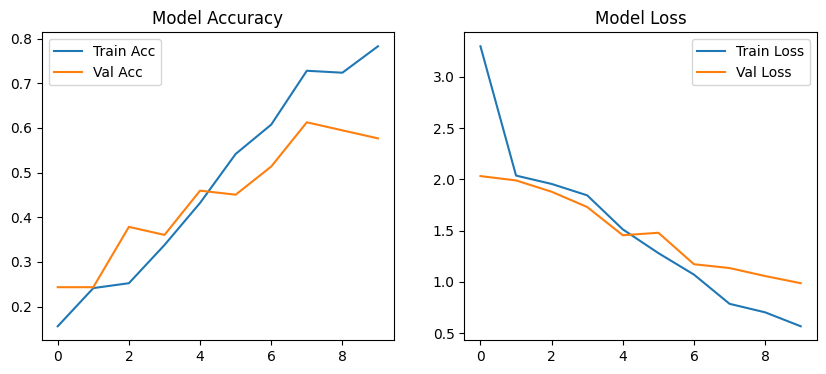

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Model Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Model Loss")

plt.show()


In [ ]:
model.save("/content/Plant_Disease_Detector.h5")
print("✅ Model saved successfully!")


✅ Model saved successfully!


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Example test image
img_path = "/plant dataset/Potato_healthy/03da9931-e514-4cc7-b04a-8f474a133ce5___RS_HL 1830.JPG"  # change to your own image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

pred = model.predict(img_array)
predicted_class = list(train_set.class_indices.keys())[np.argmax(pred)]
print("🌿 Predicted Disease:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
🌿 Predicted Disease: Potato_healthy
